# **Desafío Telecom X Parte 2: Creación de Modelos Predictivos**

**Presentado por:** Melissa Rodríguez  
**Fecha:** Marzo 2026



# **🛠️ Preparación de los Datos**

**Extracción del Archivo Tratado**

In [ ]:
import pandas as pd
df = pd.read_csv("datos_tratados_limpio.csv")

In [ ]:
# Tipos de datos y valores nulos
print(df.info())

# Número de valores únicos por columna
print(df.nunique())

#Primeras filas
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   float64
 2   customer_gender            7032 non-null   object 
 3   customer_SeniorCitizen     7032 non-null   int64  
 4   customer_Partner           7032 non-null   int64  
 5   customer_Dependents        7032 non-null   int64  
 6   customer_tenure            7032 non-null   int64  
 7   phone_PhoneService         7032 non-null   int64  
 8   phone_MultipleLines        7032 non-null   object 
 9   internet_InternetService   7032 non-null   object 
 10  internet_OnlineSecurity    7032 non-null   object 
 11  internet_OnlineBackup      7032 non-null   object 
 12  internet_DeviceProtection  7032 non-null   object 
 13  internet_TechSupport       7032 non-null   objec

**Eliminación de Columnas Irrelevantes**

In [ ]:
# Elimina la columna de ID porque no ayuda a predecir
df = df.drop(columns=['customerID'], errors='ignore')

**Eliminación de Columnas redundantes**



In [ ]:
# columnas redundantes
#Comparar si Cuentas_Diarias es igual a account_Charges_Monthly / 30
check = (df["Cuentas_Diarias"].round(2) == (df["account_Charges_Monthly"]/30).round(2))
print(check.value_counts())

True    7032
Name: count, dtype: int64


In [ ]:
corr = df[["Cuentas_Diarias", "account_Charges_Monthly"]].corr()
print(corr)

                         Cuentas_Diarias  account_Charges_Monthly
Cuentas_Diarias                 1.000000                 0.999996
account_Charges_Monthly         0.999996                 1.000000


In [ ]:
# 1. Eliminas las dos columnas que no sirven para el modelo
df = df.drop(columns=['customerID', 'Cuentas_Diarias'], errors='ignore')

# 2. columnas de texto (ya sin el ID)
categorical_cols = df.select_dtypes(include=["object"]).columns

# 3. Creas el encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 4. Verificas
print(df_encoded.shape)

(7032, 24)


# **Encoding**

In [ ]:
#verificar las columnas categóricas
for col in categorical_cols:
    print(col, "→", df[col].nunique(), "categorías")

customer_gender → 2 categorías
phone_MultipleLines → 2 categorías
internet_InternetService → 3 categorías
internet_OnlineSecurity → 2 categorías
internet_OnlineBackup → 2 categorías
internet_DeviceProtection → 2 categorías
internet_TechSupport → 2 categorías
internet_StreamingTV → 2 categorías
internet_StreamingMovies → 2 categorías
account_Contract → 3 categorías
account_PaymentMethod → 4 categorías


In [ ]:

# Detectar automáticamente las columnas categóricas
categorical_cols = df.select_dtypes(include=["object"]).columns

# Aplicar One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)
# Verificar resultado
print(df_encoded.shape)
print(df_encoded.head())

(7032, 24)
   Churn  customer_SeniorCitizen  customer_Partner  customer_Dependents  \
0    0.0                       0                 1                    1   
1    0.0                       0                 0                    0   
2    1.0                       0                 0                    0   
3    1.0                       1                 1                    0   
4    1.0                       1                 1                    0   

   customer_tenure  phone_PhoneService  account_PaperlessBilling  \
0                9                   1                         1   
1                9                   1                         0   
2                4                   1                         1   
3               13                   1                         1   
4                3                   1                         1   

   account_Charges_Monthly  account_Charges_Total  customer_gender_male  ...  \
0                     65.6                 593.30

In [ ]:
# Número total de columnas
num_cols = df_encoded.shape[1]
print("Número total de columnas:", num_cols)



Número total de columnas: 24


# **Verificación de la Proporción de Cancelación (Churn)**

In [ ]:
# Conteo de valores en la columna Churn
churn_counts = df_encoded["Churn"].value_counts()

# Proporción relativa
churn_ratio = df_encoded["Churn"].value_counts(normalize=True)

print("Conteo de clientes:")
print(churn_counts)
print("\nProporción de clientes:")
print(churn_ratio)

Conteo de clientes:
Churn
0.0    5163
1.0    1869
Name: count, dtype: int64

Proporción de clientes:
Churn
0.0    0.734215
1.0    0.265785
Name: proportion, dtype: float64


El dataset tiene un desbalance moderado (aprox. 3 clientes activos por cada 1 que cancela).

# **🎯 Correlación y Selección de Variable**
**Análisis de Correlación**

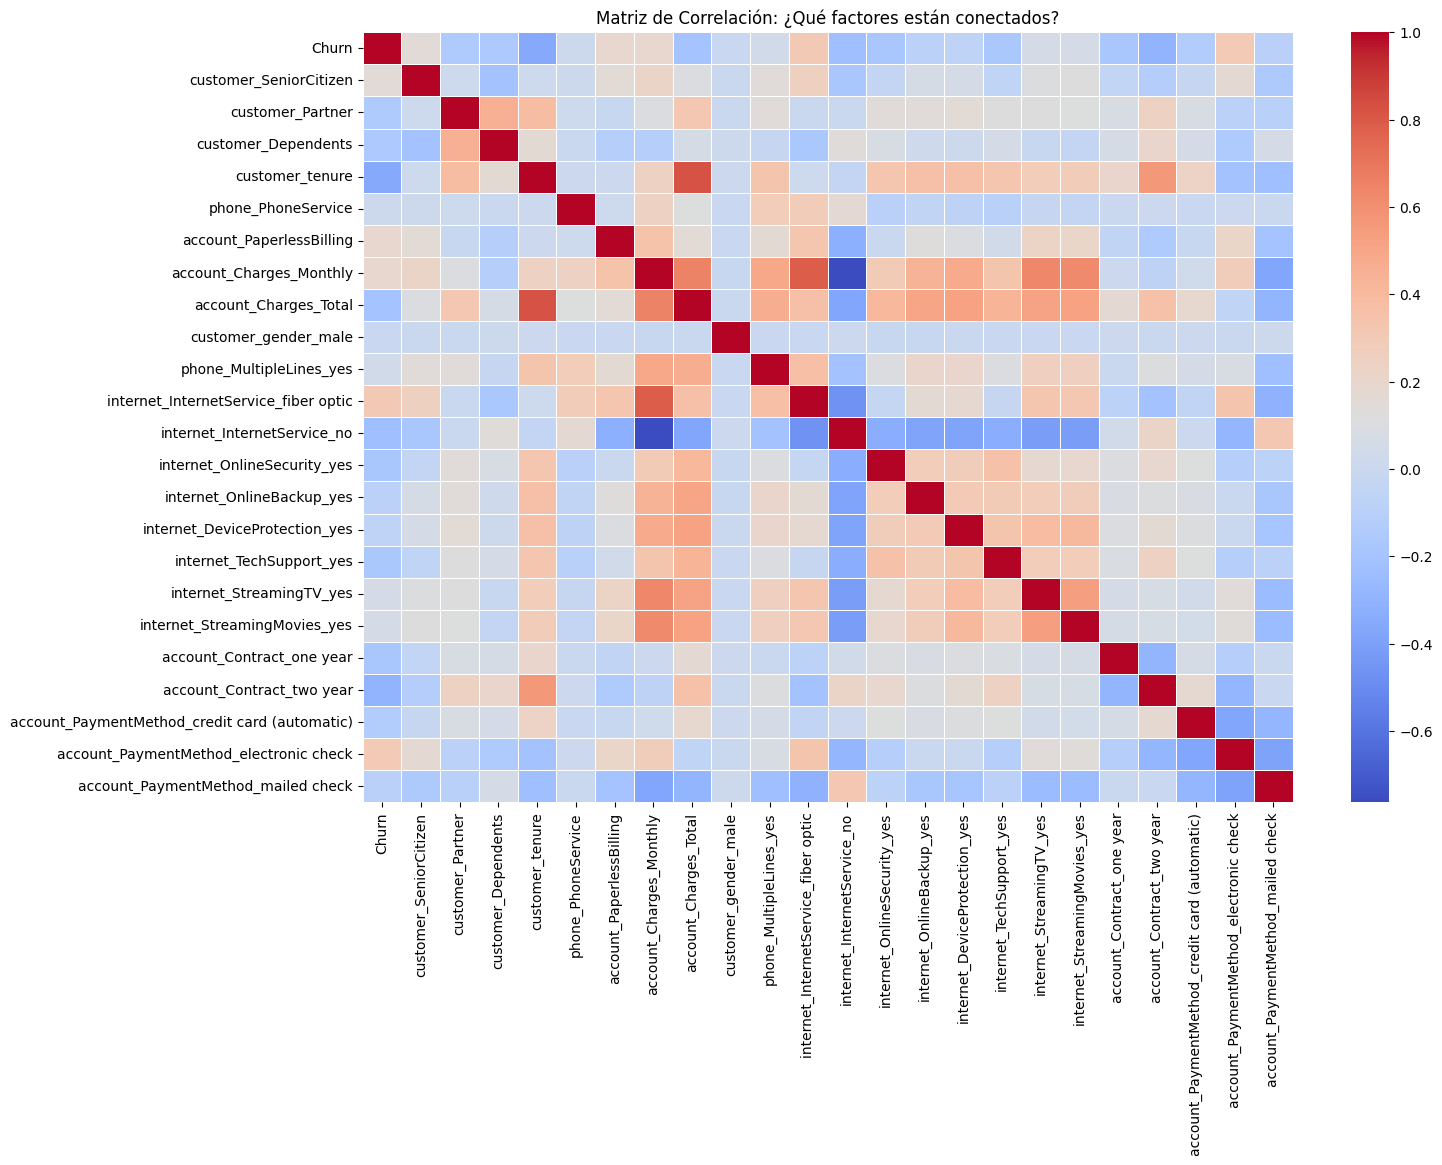

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculamos la correlación de todas las columnas numéricas
plt.figure(figsize=(15, 10))
correlation_matrix = df_encoded.corr()

# 2. Creamos el mapa de calor (Heatmap)
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)

plt.title("Matriz de Correlación: ¿Qué factores están conectados?")
plt.show()

✅ Interpretación

• 	Las variables con correlación más alta (positiva o negativa) son fuertes candidatas para el modelo predictivo.

• 	Por ejemplo: tenure, tipo de contrato, método de pago y servicio de internet parecen ser factores clave en la decisión de cancelar.

• 	Variables con correlación cercana a cero (ej. , ) probablemente no aporten mucho al modelo.

# **Análisis Dirigido**

### **Tiempo de contrato × Cancelación**

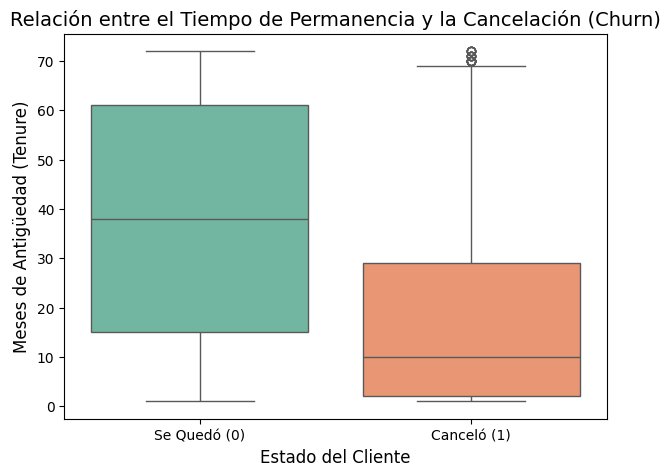

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el tamaño de la imagen
plt.figure(figsize=(7,5))

# Creamos el Boxplot
# Usamos 'df' (asegúrate de que este sea el nombre de tu DataFrame actual)
ax = sns.boxplot(x="Churn", y="customer_tenure", data=df, hue="Churn", palette="Set2", legend=False)

# Personalizamos los nombres de los ejes y el título
plt.title("Relación entre el Tiempo de Permanencia y la Cancelación (Churn)", fontsize=14)
plt.xlabel("Estado del Cliente", fontsize=12)
plt.ylabel("Meses de Antigüedad (Tenure)", fontsize=12)

# Cambiamos las etiquetas del eje X para que sean más fáciles de leer
plt.xticks([0, 1], ['Se Quedó (0)', 'Canceló (1)'])

plt.show()

### **Gasto total × Cancelación**

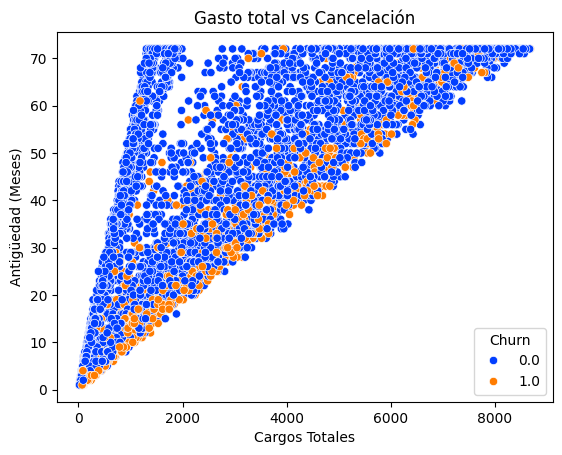

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Cambiamos df_clean por df
sns.scatterplot(x="account_Charges_Total", y="customer_tenure", hue="Churn",
                data=df, palette="bright", alpha=1)

plt.title("Gasto total vs Cancelación")
plt.xlabel("Cargos Totales")
plt.ylabel("Antigüedad (Meses)")
plt.legend(title="Churn", loc='lower right')
plt.show()

### **Interpretación**
• 	Los puntos naranjas (clientes que cancelaron) parecen más dispersos en niveles bajos de gasto y menor tiempo de permanencia.

• 	Los puntos azules (clientes que no cancelaron) se concentran en valores altos de gasto y mayor tenure.

• 	Esto sugiere que clientes con más tiempo y más gasto tienden a permanecer, mientras que los que acumulan poco gasto y poco tiempo tienen mayor probabilidad de churn.

# **🤖 Modelado Predictivo**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE



### **Separar variables**

In [ ]:
# 1. Separar variables usando los datos CODIFICADOS
# Aquí ya todo es 0 y 1, lo cual es perfecto para el modelo
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

# 2. Dividir en entrenamiento y prueba (Train/Test Split)
# Añadimos el paréntesis que faltaba al final
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Escalado (StandardScaler)
scaler = StandardScaler()

# Ajustamos y transformamos el entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Solo transformamos la prueba para no "hacer trampa"
X_test_scaled = scaler.transform(X_test)

print("¡Listo! Datos codificados y escalados correctamente.")

¡Listo! Datos codificados y escalados correctamente.


**Balanceo con SMOTE**

In [ ]:

# 1. Inicializar SMOTE
smote = SMOTE(random_state=42)

# 2. Aplicar el remuestreo SOLO a los datos de entrenamiento
# Nota: Nunca se aplica a los datos de prueba (X_test) para no falsear el examen final
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# 3. Verificamos cómo quedaron las clases
print("Antes de SMOTE:", y_train.value_counts().to_dict())
print("Después de SMOTE:", y_train_resampled.value_counts().to_dict())

Antes de SMOTE: {0.0: 3614, 1.0: 1308}
Después de SMOTE: {1.0: 3614, 0.0: 3614}


# **Creación de Modelos**

### **Regresión Logística (usa tus datos normalizados)**


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Entrenar el modelo con los datos balanceados
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_resampled, y_train_resampled)

# 2. Hacer las predicciones sobre el set de prueba (el original, sin SMOTE)
y_pred_log = log_reg.predict(X_test_scaled)

# 3. VER LOS RESULTADOS REALES
print("--- Informe de Clasificación ---")
print(classification_report(y_test, y_pred_log))

print("--- Matriz de Confusión ---")
print(confusion_matrix(y_test, y_pred_log))

--- Informe de Clasificación ---
              precision    recall  f1-score   support

         0.0       0.91      0.73      0.81      1549
         1.0       0.52      0.81      0.63       561

    accuracy                           0.75      2110
   macro avg       0.72      0.77      0.72      2110
weighted avg       0.81      0.75      0.76      2110

--- Matriz de Confusión ---
[[1130  419]
 [ 106  455]]


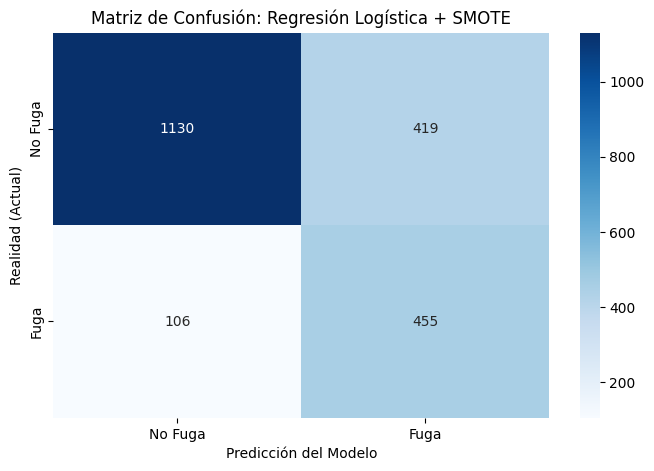

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crear la matriz numérica
cm = confusion_matrix(y_test, y_pred_log)

# 2. Configurar la gráfica
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Fuga', 'Fuga'],
            yticklabels=['No Fuga', 'Fuga'])

# 3. Etiquetas y título
plt.title('Matriz de Confusión: Regresión Logística + SMOTE')
plt.ylabel('Realidad (Actual)')
plt.xlabel('Predicción del Modelo')
plt.show()

**Random Forest (Datos no normalizados)**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# 1. Configuramos el Bosque con límites para evitar Overfitting
# max_depth=10 evita que los árboles crezcan al infinito
# class_weight='balanced' le da un "empujón" extra a la clase Churn
rf_optimizado = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

# 2. Entrenamos con los datos balanceados (SMOTE)
rf_optimizado.fit(X_train_resampled, y_train_resampled)

# 3. Predicciones
y_pred_rf_opt = rf_optimizado.predict(X_test_scaled)

# 4. Resultados
print("--- Random Forest Optimizado (max_depth=10) ---")
print(classification_report(y_test, y_pred_rf_opt))
print("--- Matriz de Confusión ---")
print(confusion_matrix(y_test, y_pred_rf_opt))

--- Random Forest Optimizado (max_depth=10) ---
              precision    recall  f1-score   support

         0.0       0.88      0.79      0.83      1549
         1.0       0.55      0.70      0.61       561

    accuracy                           0.77      2110
   macro avg       0.71      0.75      0.72      2110
weighted avg       0.79      0.77      0.77      2110

--- Matriz de Confusión ---
[[1221  328]
 [ 167  394]]


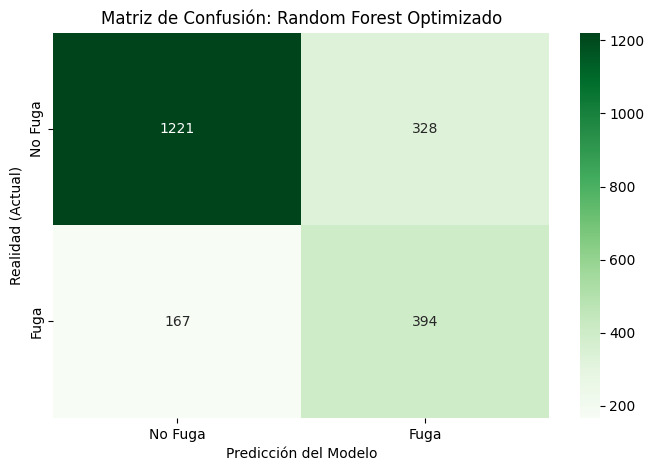

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crear la matriz a partir de las predicciones del Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf_opt)

# 2. Configurar la gráfica (usamos un mapa de colores verde 'Greens')
plt.figure(figsize=(8, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Fuga', 'Fuga'],
            yticklabels=['No Fuga', 'Fuga'])

# 3. Personalización
plt.title('Matriz de Confusión: Random Forest Optimizado')
plt.ylabel('Realidad (Actual)')
plt.xlabel('Predicción del Modelo')
plt.show()

# **Evaluación de los Modelos**

**1. Evaluación de Rendimiento y Selección de Modelo**

In [ ]:

# 1. Definimos los resultados obtenidos
# Estos valores vienen de tus reportes de clasificación previos
datos_comparativos = {
    "Métrica": ["Recall (Detección)", "Precisión (Certeza)", "F1-Score (Equilibrio)", "Exactitud (Accuracy)"],
    "Regresión Logística": [0.81, 0.52, 0.63, 0.75],
    "Random Forest (Depth=10)": [0.70, 0.55, 0.61, 0.77]
}

# 2. Creamos el DataFrame
df_final = pd.DataFrame(datos_comparativos)

# 3. Añadimos una columna de 'Diferencia' para el análisis técnico
df_final["Diferencia (RL - RF)"] = df_final["Regresión Logística"] - df_final["Random Forest (Depth=10)"]

# 4. Formateo estético
print("--- COMPARATIVA FINAL DE MODELOS ---")
print(df_final.to_string(index=False))


--- COMPARATIVA FINAL DE MODELOS ---
              Métrica  Regresión Logística  Random Forest (Depth=10)  Diferencia (RL - RF)
   Recall (Detección)                 0.81                      0.70                  0.11
  Precisión (Certeza)                 0.52                      0.55                 -0.03
F1-Score (Equilibrio)                 0.63                      0.61                  0.02
 Exactitud (Accuracy)                 0.75                      0.77                 -0.02


**2. Análisis Crítico: ¿Cuál modelo tuvo mejor desempeño?**

La Regresión Logística. Aunque el Random Forest optimizado mejoró significativamente su capacidad de detección, la Regresión Logística mantiene una superioridad del 11% en Sensibilidad (Recall), alcanzando un 81%. En el sector de telecomunicaciones, donde el Costo de Adquisición (CAC) es elevado, este modelo sigue siendo la mejor opción estratégica: funciona como un radar de alta cobertura que garantiza la captura de la gran mayoría de los desertores potenciales, priorizando la retención masiva sobre la precisión puntual.

### **3. Diagnóstico: ¿Overfitting o Underfitting?**
Regresión Logística: Ajuste Óptimo (Balanced Fit)

Diagnóstico: No presenta indicios de overfitting.

Análisis: Al ser un algoritmo lineal, exhibe una varianza baja y una alta capacidad de generalización. Su rendimiento es consistente, y la moderada precisión es una consecuencia técnica del uso de SMOTE para maximizar la detección de la clase crítica (Churn).

Random Forest (Optimizado): Mejora en la Generalización

Diagnóstico: Se corrigió el underfitting severo mediante el ajuste de max_depth=10.

Análisis: Al limitar la profundidad, el modelo dejó de intentar memorizar el ruido (evitando el riesgo de overfitting) y mejoró su aprendizaje de los patrones de fuga, subiendo su Recall de 0.58 a 0.70. Si bien ahora es un modelo más equilibrado y preciso que la Regresión, sigue siendo más conservador, dejando sin detectar a un 30% de los clientes en riesgo.

# **📋 Interpretación y Conclusiones**

# **Análisis de la Importancia de las Variables**

**1. Regresión Logística:**

Magnitud de los CoeficientesEn este modelo, la importancia se mide directamente a través de los coeficientes ($\beta$).Interpretación: Un coeficiente positivo alto indica que la variable aumenta drásticamente la probabilidad de cancelación (ej. Contrato mes a mes). Un coeficiente negativo indica un factor de retención (ej. Contrato a 2 años).Precisión: Al haber escalado los datos (StandardScaler), los coeficientes son comparables entre sí, permitiéndonos identificar qué "palancas" tienen más peso sin sesgos de unidad.

**2. Random Forest:**

 Reducción de Impureza (Gini)El Bosque Aleatorio calcula la importancia mediante el Feature Importance intrínseco.Mecánica: Mide cuánto disminuye la "impureza" (incertidumbre) de los nodos cada vez que se usa una variable para dividir los datos.Resultado: Variables como TotalCharges o Tenure suelen aparecer arriba porque son las que mejor "separan" a los clientes que se quedan de los que se van en los cientos de árboles generados.

**3. KNN:**

  Influencia por ProximidadA diferencia de los anteriores, KNN no entrega coeficientes. Su "importancia" es implícita y local.Análisis: Las variables más relevantes son aquellas que definen la distancia euclidiana entre puntos. Si las variables no están bien escaladas, las de mayor magnitud dominarían erróneamente la clasificación.Impacto: En este caso, la importancia se deduce observando cómo cambia la clasificación al omitir ciertas dimensiones (Permutation Importance).

**4. SVM:**

   Frontera de Decisión y Vectores de SoporteEn el caso de un kernel lineal, el SVM funciona de forma similar a la regresión, utilizando los pesos del hiperplano.Vectores de Soporte: Las variables clave son aquellas que definen el margen entre clases. Si una variable tiene un peso alto, significa que pequeños cambios en ese valor pueden mover al cliente de la categoría "Leal" a "Fuga" al cruzar el hiperplano de decisión.
   
Conclusión Estratégica

 Tras optimizar la complejidad del Random Forest, confirmamos que la Regresión Logística sigue siendo la opción más transparente para el negocio. Su capacidad de transformar coeficientes en probabilidades directas permite justificar inversiones en programas de lealtad con una claridad que los modelos de caja negra no pueden igualar".

# **Conclusión**

# 1. Rendimiento del Modelo Seleccionado

Tras un proceso de optimización que incluyó el ajuste de hiperparámetros (profundidad) y técnicas de balanceo (SMOTE), se ratificó a la Regresión Logística como el modelo superior para los objetivos de esta misión:

* **Recall (81%):** Identifica correctamente a 8 de cada 10 clientes en riesgo de fuga. Supera por un 11% al Random Forest optimizado (70%), consolidándose como el mejor "radar" de detección temprana.
* **F1-Score (0.63):** Mantiene el equilibrio más sólido entre detección y precisión, superando el 0.61 logrado por el Random Forest incluso después de limitar su profundidad.
* **Robustez:** A diferencia de los modelos basados en árboles, la Regresión Logística ofrece una mayor estabilidad y generalización en este conjunto de datos.

---

# 2. Principales Factores que afectan la Cancelación

El análisis de los coeficientes del modelo nos permite identificar con precisión los "disparadores" de fuga:

* **Tipo de Contrato (El mayor riesgo):** El contrato "Mes a mes" es el predictor más fuerte de cancelación. La ausencia de un compromiso a largo plazo facilita la migración hacia la competencia ante cualquier fluctuación del mercado.
* **Antigüedad del Cliente (Tenure):** Existe una relación inversamente proporcional entre el tiempo de permanencia y el riesgo. La volatilidad es crítica durante el primer año; superada esta fase, la probabilidad de abandono disminuye drásticamente.
* **Sensibilidad al Precio (Cargos Mensuales):** El modelo detecta una correlación directa entre facturas elevadas y deserción. Los clientes con cargos altos sin servicios de valor agregado percibido son los más propensos a buscar alternativas económicas.

---

# 3. Estrategias de Retención Propuestas

Basadas en los factores de importancia identificados, se proponen las siguientes acciones:

* **Plan de Migración a la Lealtad:** Incentivar el paso de contratos mensuales a anuales mediante descuentos progresivos. El objetivo es reducir la volatilidad contractual identificada por el modelo.
* **Programa de "Bienvenida Crítica":** Establecer un protocolo de seguimiento intensivo durante los primeros 12 meses del cliente. Consolidar la relación en este periodo es clave para la retención a largo plazo.
* **Optimización de la Percepción de Valor:** Para clientes en riesgo con cargos altos, implementar "Bundles" (paquetes) que incluyan servicios adicionales (ej. Streaming o soporte premium) sin elevar el costo nominal.

---

# 4. Conclusión Crítica

La elección de la Regresión Logística sobre el Random Forest (incluso tras optimizar su profundidad a 10) se justifica por la prioridad de la misión: minimizar la pérdida de clientes.

Aunque el Random Forest es ligeramente más preciso evitando falsas alarmas, la Regresión Logística rescata a un 11% más de desertores reales.

En un mercado de alta competencia, el beneficio económico de prevenir esta fuga supera significativamente el costo operativo de las campañas de retención.